**REPORT:Analysis of Daily Birth Patterns in the US (2000–2014**

**Abstract**:This report analyzes the US births dataset from 2000–2014 to study daily birth patterns. 
The data is cleaned and analyzed to compare birth counts across different days of the week. 
Statistical measures and visualizations are used to identify trends, variability, and outliers in birth distributions.

**2.Data preprocessing**

   **2.1 Import Required Libraries**


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Libraries imported successfully for data analysis.

**2.2 Load the Dataset**

In [8]:
df=pd.read_csv("US_births_2000-2014_SSA.csv")


The dataset US_births_2000-2014_SSA.csv was loaded into a Pandas DataFrame to begin the analysis.

**2.3 Inspecting Dataset Structure and Summary Statistics**

In [11]:
df.head(6)

,year,month,date_of_month,day_of_week,births,date
0,2000,1,1.0,6,9083.0,01-01-2000
1,2000,1,2.0,7,8006.0,01-02-2000
2,2000,1,3.0,1,11363.0,01-03-2000
3,2000,1,4.0,2,13032.0,01-04-2000
4,2000,1,5.0,3,12558.0,01-05-2000
5,2000,1,6.0,4,NaN,01-06-2000


Displays the first 6 rows of the dataset to quickly preview the data.

In [13]:
df.tail(7)

,year,month,date_of_month,day_of_week,births,date
5472,2014,12,25.0,4,6749.0,12/25/2014
5473,2014,12,26.0,5,10386.0,12/26/2014
5474,2014,12,27.0,6,8656.0,12/27/2014
5475,2014,12,28.0,7,7724.0,12/28/2014
5476,2014,12,29.0,1,12811.0,12/29/2014
5477,2014,12,30.0,2,13634.0,12/30/2014
5478,2014,12,NaN,3,11990.0,12/31/2014


Displays the last 7  rows of the dataset to quickly preview the data.

In [15]:
df.describe()

,year,month,date_of_month,day_of_week,births
count,5479.000000,5479.000000,5478.000000,5479.000000,5465.000000
mean,2006.999270,6.522723,15.727455,3.999817,11348.814456
std,4.321085,3.449075,8.799535,2.000502,2327.445105
min,2000.000000,1.000000,1.000000,1.000000,5728.000000
25%,2003.000000,4.000000,8.000000,2.000000,8739.000000
50%,2007.000000,7.000000,16.000000,4.000000,12343.000000
75%,2011.000000,10.000000,23.000000,6.000000,13083.000000
max,2014.000000,12.000000,31.000000,7.000000,16081.000000


Shows summary statistics such as count, mean, standard deviation, minimum, maximum, and quartile values for numerical columns.

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5479 entries, 0 to 5478
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   year           5479 non-null   int64  
 1   month          5479 non-null   int64  
 2   date_of_month  5478 non-null   float64
 3   day_of_week    5479 non-null   int64  
 4   births         5465 non-null   float64
 5   date           5479 non-null   object 
dtypes: float64(2), int64(3), object(1)
memory usage: 257.0+ KB


Displays dataset structure including column names, data types, non-null values, and memory usage.

**3.Data wrangling**


Data wrangling involves cleaning and transforming the dataset so it is suitable for analysis

**3.1 Checking for null values**

In [22]:
df.isnull().sum()

year              0
month             0
date_of_month     1
day_of_week       0
births           14
date              0
dtype: int64

14 null values are present in births and 1 null values in date_of_month

In [24]:
df[df.isnull().any(axis=1)]

,year,month,date_of_month,day_of_week,births,date
5,2000,1,6.0,4,NaN,01-06-2000
10,2000,1,11.0,2,NaN,01-11-2000
12,2000,1,13.0,4,NaN,1/13/2000
49,2000,2,19.0,6,NaN,2/19/2000
95,2000,4,5.0,3,NaN,04-05-2000
150,2000,5,30.0,2,NaN,5/30/2000
151,2000,5,31.0,3,NaN,5/31/2000
152,2000,6,1.0,4,NaN,06-01-2000
292,2000,10,19.0,4,NaN,10/19/2000
293,2000,10,20.0,5,NaN,10/20/2000


Displays rows in the dataset that contain missing values.

In [26]:
df.isnull().sum().sum()

15

It displays the total null values in the dataset ,it is identified as 15 null values are present

**3.1.1 Fill Null Values Using Mean**

In [29]:
df['births'].fillna(df['births'].mean(), inplace=True)
df['date_of_month'].fillna(df['date_of_month'].mean(), inplace=True)

C:\Users\dell\AppData\Local\Temp\ipykernel_27540\2268048560.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['births'].fillna(df['births'].mean(), inplace=True)
C:\Users\dell\AppData\Local\Temp\ipykernel_27540\2268048560.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For

Missing values in the births column and date_of_month column are replaced with the mean value of the column.

In [31]:
df.isnull().sum()

year             0
month            0
date_of_month    0
day_of_week      0
births           0
date             0
dtype: int64

Missing values in selected columns are replaced using the mean of each column.

**3.2 Checking for Duplicate Rows**

In [ ]:
df.duplicated().sum()

Displays the total number of duplicate rows present in the dataset.There is no duplicates present in the dataset

**Average number of births per day for each day of the week**

In [72]:

df.groupby('day_of_week')['births'].mean()

day_of_week
1    12144.838283
2    13183.893200
3    12963.638589
4    13000.486506
5    12704.423754
6     8565.750721
7     7522.620453
Name: births, dtype: float64

The result shows that Tuesday has the highest average number of births while Sunday has the lowest average births among all days of the week.

**Median number of births per day for each day of the week**

In [74]:
df.groupby("day_of_week")["births"].median()

day_of_week
1    12140.0
2    13205.0
3    12947.0
4    12980.0
5    12662.0
6     8574.0
7     7512.0
Name: births, dtype: float64

Displays the median number of births per day for each day of the week, showing that Tuesday has the highest median births while Sunday has the lowest

**Remove all rows where weekday births are less than 10,000**

In [37]:
df = df[~((df['day_of_week'] <= 5) & (df['births'] < 10000))]

In [39]:
df

,year,month,date_of_month,day_of_week,births,date
0,2000,1,1.000000,6,9083.0,01-01-2000
1,2000,1,2.000000,7,8006.0,01-02-2000
2,2000,1,3.000000,1,11363.0,01-03-2000
3,2000,1,4.000000,2,13032.0,01-04-2000
4,2000,1,5.000000,3,12558.0,01-05-2000
...,...,...,...,...,...,...
5474,2014,12,27.000000,6,8656.0,12/27/2014
5475,2014,12,28.000000,7,7724.0,12/28/2014
5476,2014,12,29.000000,1,12811.0,12/29/2014
5477,2014,12,30.000000,2,13634.0,12/30/2014


 It removes all rows where the day is a weekday (1–5) and the number of births is less than 10,000, reducing the dataset to 5367 rows.

**Dispersed are the number of births per day for each day of the week**

In [44]:
df.groupby('day_of_week')['births'].std()

day_of_week
1    629.187372
2    693.874302
3    739.740123
4    732.011107
5    753.067584
6    508.575162
7    422.341561
Name: births, dtype: float64

The standard deviation of births for each day of the week, indicating the level of dispersion in daily birth counts.

**Interquartile range (IQR) of the number of births per day for each day of the week**

In [50]:
Q1 = df.groupby('day_of_week')['births'].quantile(0.25)
Q3 = df.groupby('day_of_week')['births'].quantile(0.75)

IQR = Q3 - Q1
IQR

day_of_week
1    863.0
2    891.0
3    936.0
4    950.5
5    952.0
6    606.5
7    518.0
Name: births, dtype: float64

The IQR results show that weekday births have greater variability than weekend births, with Friday having the largest spread and Sunday the smallest.

**Outliers for the number of births per day for each day of the week** 

In [54]:
outliers = {}
for day, group in df.groupby('day_of_week'):   
    Q1 = group['births'].quantile(0.25)
    Q3 = group['births'].quantile(0.75)
    IQR = Q3 - Q1   
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR    
    outliers[day] = group[(group['births'] < lower) | (group['births'] > upper)]
for day in outliers:
    print("Day", day, "Outliers:", len(outliers[day]))

Day 1 Outliers: 8
Day 2 Outliers: 13
Day 3 Outliers: 13
Day 4 Outliers: 14
Day 5 Outliers: 14
Day 6 Outliers: 15
Day 7 Outliers: 6


The results show that Saturday has the highest number of outliers (15),
while Sunday has the lowest (6),
indicating that unusual birth counts occur more frequently on some days compared to others.

**4.Data visulaization**

**Box and Whisker plots for the number of births per day for each day of the week**

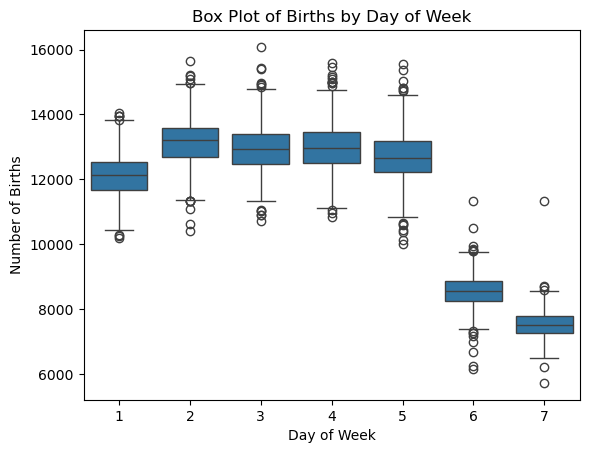

In [63]:
sns.boxplot(x='day_of_week', y='births', data=df)

plt.title("Box Plot of Births by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Births")

plt.show()

The box plot helps visualize the spread and variability of births across different days, highlighting the median, interquartile range, and potential outliers for each day.

**Histogram Plot of Births per Day of the Week**

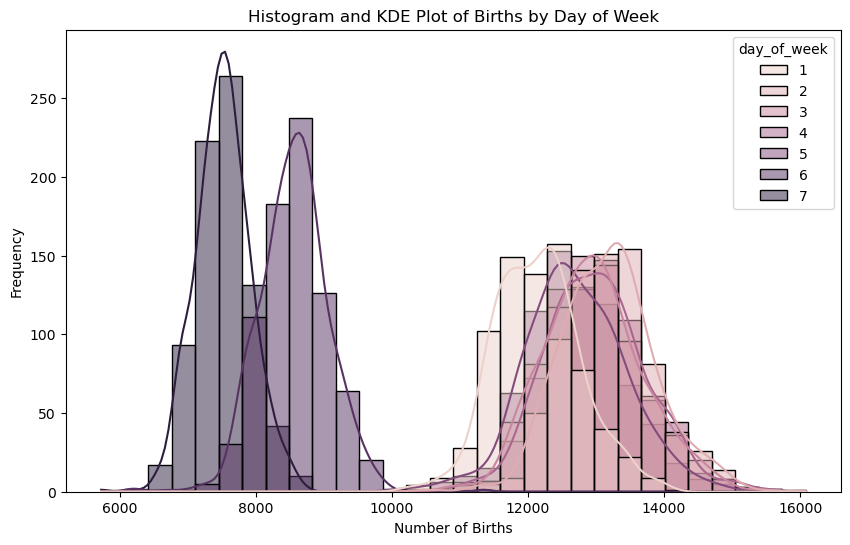

In [69]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='births', hue='day_of_week', kde=True, bins=30)
plt.title("Histogram and KDE Plot of Births by Day of Week")
plt.xlabel("Number of Births")
plt.ylabel("Frequency")
plt.show()

The histogram shows the frequency distribution of births, while the KDE plot provides a smoothed density curve to better understand the distribution pattern of births across different days.

**Day of the year 50% of births have occurred for each year** 

In [79]:
df['day_of_year'] = pd.to_datetime(df['date'], format='mixed').dt.dayofyear
df = df.sort_values(['year', 'day_of_year'])
result = {}
for year, data in df.groupby('year'):    
    cumulative_births = data['births'].cumsum()
    total_births = data['births'].sum()
    day_50 = data[cumulative_births >= total_births/2].iloc[0]['day_of_year'] 
    result[year] = day_50
print(result)

{2000: 187, 2001: 184, 2002: 184, 2003: 186, 2004: 185, 2005: 186, 2006: 188, 2007: 186, 2008: 183, 2009: 183, 2010: 184, 2011: 186, 2012: 188, 2013: 187, 2014: 186}


 **In 2000, between what days of the year do 50% of births occur**


In [82]:

df['day_of_year'] = pd.to_datetime(df['date'], format='mixed').dt.dayofyear
data_2000 = df[df['year'] == 2000].sort_values('day_of_year')
cum = data_2000['births'].cumsum()
total = data_2000['births'].sum()
start_day = data_2000[cum >= total*0.25].iloc[0]['day_of_year']
end_day = data_2000[cum >= total*0.75].iloc[0]['day_of_year']
print(start_day, end_day)

93 274


In the year 2000, the middle 50% of births occurred between the 93rd day and the 274th day of the year.

**Conclusion**


This analysis examined the **US births dataset from 2000–2014** to identify patterns in daily birth counts. Data preprocessing and wrangling were performed to clean the dataset by handling missing values and removing irregular records. Statistical measures such as **mean, median, standard deviation, and IQR** were used to study the distribution of births across days of the week. The results showed that **weekday births are generally higher than weekend births**, with **Tuesday having the highest average births and Sunday the lowest**. Visualization techniques like **box plots, histograms, and KDE plots** helped illustrate the variability and distribution of birth counts. Additionally, cumulative analysis showed that in **2000, the middle 50% of births occurred between the 93rd and 274th day of the year**.